In [1]:
pip install google-cloud-bigquery pandas matplotlib

  Using cached google_cloud_bigquery-3.46.1-py3-none-any.whl.metadata (8.5 kB)
  Using cached grpcio_status-1.84.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached protobuf-6.33.6-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
  Using cached grpcio-1.84.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.8 kB)
Using cached google_cloud_bigquery-3.46.1-py3-none-any.whl (268 kB)
Using cached grpcio_status-1.84.0-py3-none-any.whl (14 kB)
Using cached grpcio-1.84.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (7.2 MB)
Using cached protobuf-6.33.6-cp39-abi3-manylinux2014_x86_64.whl (323 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.3
    Uninstalling protobuf-5.29.3:
      Successfully uninstalled protobuf-5.29.3
  Attempting uninstall: grpcio
    Found existing installation: grpcio 1.71.0
    Uninstalling grpcio-1.71.0:
      Successfully uninstalled grpcio-1.71.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [12]:
import sys

print("Python:", sys.executable)

!{sys.executable} -m pip install --upgrade db-dtypes

Python: /home/eric/miniconda3/envs/bde/bin/python


In [13]:
import sys
import db_dtypes

print("Python:", sys.executable)
print("db_dtypes:", db_dtypes.__file__)

Python: /home/eric/miniconda3/envs/bde/bin/python
db_dtypes: /home/eric/miniconda3/envs/bde/lib/python3.11/site-packages/db_dtypes/__init__.py


In [1]:
import db_dtypes
print("db-dtypes is working")

db-dtypes is working


In [2]:
from google.cloud import bigquery

client = bigquery.Client(
    project="sg-ev-charging-analytics"
)

query = """
SELECT *
FROM `sg-ev-charging-analytics.ev_analytics.ev_charging_points`
"""

df = client.query(query).to_dataframe()

print(df.shape)
df.head()

/home/eric/miniconda3/envs/bde/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(11560, 18)


,ev_cp_id,station_name,charging_point_name,address,postal_code,latitude,longitude,operator,plug_type,power_rating_kw,price,price_type,charger_status,operating_hours,position,last_updated_time,ev_id_status,ingestion_timestamp
0,R127550A-001,MILLENIA WALK,MILLENIA WALK,9 RAFFLES BOULEVARD SINGAPORE 039596,039596,1.292605,103.859725,TESLA MOTORS SINGAPORE PRIVATE LIMITED,Type 2,22.0,NaN,,0,,B1 197,2026-10-03 14:40:00+00:00,0,2026-10-03 07:04:04.204379+00:00
1,R109856B-001,MILLENIA WALK,MILLENIA WALK,9 RAFFLES BOULEVARD SINGAPORE 039596,039596,1.292605,103.859725,TESLA MOTORS SINGAPORE PRIVATE LIMITED,Type 2,22.0,NaN,,0,,B1 197,2026-10-03 14:40:00+00:00,0,2026-10-03 07:04:04.204379+00:00
2,R109860F-001,MILLENIA WALK,MILLENIA WALK,9 RAFFLES BOULEVARD SINGAPORE 039596,039596,1.292605,103.859725,TESLA MOTORS SINGAPORE PRIVATE LIMITED,Type 2,22.0,NaN,,0,,B1 193,2026-10-03 14:40:00+00:00,0,2026-10-03 07:04:04.204379+00:00
3,R131821D-001,ONE RAFFLES QUAY,ONE RAFFLES QUAY,1 RAFFLES QUAY SINGAPORE 048583,048583,1.281182,103.851899,CHARGE+ PTE. LTD.,Type 2,22.0,NaN,,100,,L4 41,2026-10-03 14:40:00+00:00,<NA>,2026-10-03 07:04:04.204379+00:00
4,R131823A-001,ONE RAFFLES QUAY,ONE RAFFLES QUAY,1 RAFFLES QUAY SINGAPORE 048583,048583,1.281182,103.851899,CHARGE+ PTE. LTD.,Type 2,22.0,NaN,,100,,L4 42,2026-10-03 14:40:00+00:00,<NA>,2026-10-03 07:04:04.204379+00:00


In [3]:
df.shape

(11560, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11560 entries, 0 to 11559
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   ev_cp_id             11560 non-null  object             
 1   station_name         11560 non-null  object             
 2   charging_point_name  11560 non-null  object             
 3   address              11560 non-null  object             
 4   postal_code          11560 non-null  object             
 5   latitude             11560 non-null  float64            
 6   longitude            11560 non-null  float64            
 7   operator             11560 non-null  object             
 8   plug_type            11560 non-null  object             
 9   power_rating_kw      11560 non-null  float64            
 10  price                11356 non-null  float64            
 11  price_type           11560 non-null  object             
 12  charger_status    

In [5]:
operator_df = (
    df.groupby("operator")["ev_cp_id"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

operator_df

operator
SP MOBILITY PTE. LTD.                     2795
CHARGE+ PTE. LTD.                         2630
COMFORTDELGRO ENGIE PTE. LTD.             2069
SHELL SINGAPORE PTE. LTD.                 1842
STRIDES YTL PTE. LTD.                     1124
VOLT SINGAPORE PTE. LTD.                   335
MNL SOLUTIONS PTE. LTD.                    111
GREAT CHARGE PTE. LTD.                      84
TESLA MOTORS SINGAPORE PRIVATE LIMITED      71
FASTPARKNCHARGE PTE. LTD.                   69
Name: ev_cp_id, dtype: int64

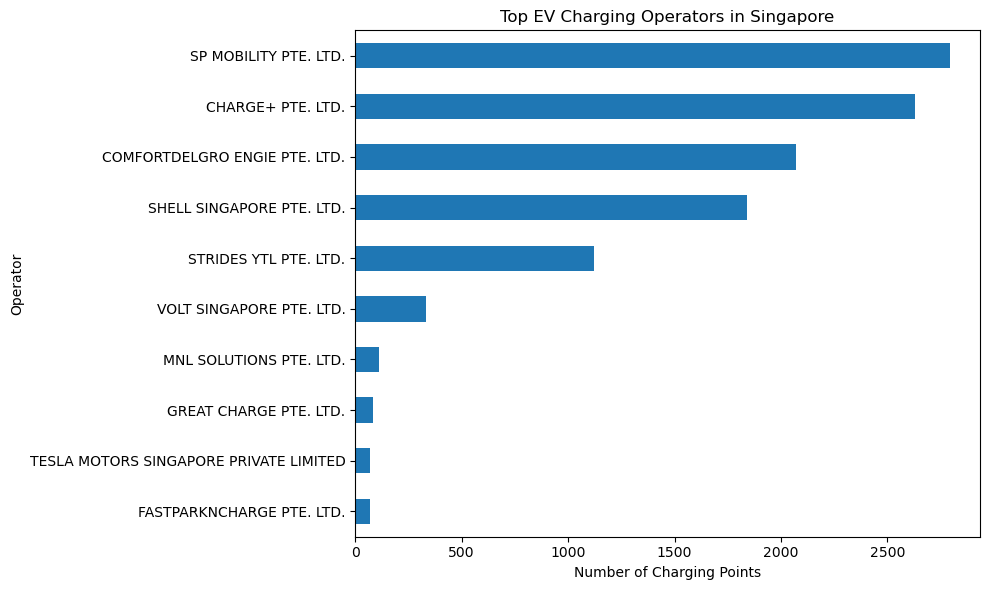

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

operator_df.sort_values().plot(
    kind="barh"
)

plt.title("Top EV Charging Operators in Singapore")
plt.xlabel("Number of Charging Points")
plt.ylabel("Operator")

plt.tight_layout()
plt.show()

In [7]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())

Rows: 11560
Columns: 18


,ev_cp_id,station_name,charging_point_name,address,postal_code,latitude,longitude,operator,plug_type,power_rating_kw,price,price_type,charger_status,operating_hours,position,last_updated_time,ev_id_status,ingestion_timestamp
0,R127550A-001,MILLENIA WALK,MILLENIA WALK,9 RAFFLES BOULEVARD SINGAPORE 039596,039596,1.292605,103.859725,TESLA MOTORS SINGAPORE PRIVATE LIMITED,Type 2,22.0,NaN,,0,,B1 197,2026-10-03 14:40:00+00:00,0,2026-10-03 07:04:04.204379+00:00
1,R109856B-001,MILLENIA WALK,MILLENIA WALK,9 RAFFLES BOULEVARD SINGAPORE 039596,039596,1.292605,103.859725,TESLA MOTORS SINGAPORE PRIVATE LIMITED,Type 2,22.0,NaN,,0,,B1 197,2026-10-03 14:40:00+00:00,0,2026-10-03 07:04:04.204379+00:00
2,R109860F-001,MILLENIA WALK,MILLENIA WALK,9 RAFFLES BOULEVARD SINGAPORE 039596,039596,1.292605,103.859725,TESLA MOTORS SINGAPORE PRIVATE LIMITED,Type 2,22.0,NaN,,0,,B1 193,2026-10-03 14:40:00+00:00,0,2026-10-03 07:04:04.204379+00:00
3,R131821D-001,ONE RAFFLES QUAY,ONE RAFFLES QUAY,1 RAFFLES QUAY SINGAPORE 048583,048583,1.281182,103.851899,CHARGE+ PTE. LTD.,Type 2,22.0,NaN,,100,,L4 41,2026-10-03 14:40:00+00:00,<NA>,2026-10-03 07:04:04.204379+00:00
4,R131823A-001,ONE RAFFLES QUAY,ONE RAFFLES QUAY,1 RAFFLES QUAY SINGAPORE 048583,048583,1.281182,103.851899,CHARGE+ PTE. LTD.,Type 2,22.0,NaN,,100,,L4 42,2026-10-03 14:40:00+00:00,<NA>,2026-10-03 07:04:04.204379+00:00


In [8]:
df.isna().sum().sort_values(ascending=False)

ev_id_status           366
price                  204
station_name             0
ev_cp_id                 0
charging_point_name      0
address                  0
longitude                0
operator                 0
postal_code              0
latitude                 0
power_rating_kw          0
plug_type                0
charger_status           0
price_type               0
operating_hours          0
position                 0
last_updated_time        0
ingestion_timestamp      0
dtype: int64

In [9]:
total_charging_points = df["ev_cp_id"].nunique()
total_stations = df["station_name"].nunique()
total_operators = df["operator"].nunique()
total_plug_types = df["plug_type"].nunique()

avg_power = df["power_rating_kw"].mean()
avg_price = df["price"].mean()

print(f"Total charging points : {total_charging_points:,}")
print(f"Total stations        : {total_stations:,}")
print(f"Total operators       : {total_operators:,}")
print(f"Total plug types      : {total_plug_types:,}")
print(f"Average power         : {avg_power:.2f} kW")
print(f"Average price         : ${avg_price:.2f}")

Total charging points : 11,560
Total stations        : 2,586
Total operators       : 29
Total plug types      : 3
Average power         : 24.54 kW
Average price         : $0.70


In [10]:
operator_df = (
    df.groupby("operator")["ev_cp_id"]
      .nunique()
      .sort_values(ascending=False)
)

operator_df

operator
SP MOBILITY PTE. LTD.                     2795
CHARGE+ PTE. LTD.                         2630
COMFORTDELGRO ENGIE PTE. LTD.             2069
SHELL SINGAPORE PTE. LTD.                 1842
STRIDES YTL PTE. LTD.                     1124
VOLT SINGAPORE PTE. LTD.                   335
MNL SOLUTIONS PTE. LTD.                    111
GREAT CHARGE PTE. LTD.                      84
TESLA MOTORS SINGAPORE PRIVATE LIMITED      71
FASTPARKNCHARGE PTE. LTD.                   69
EV MOBILITY PTE. LTD.                       63
KED ENERGY PTE. LTD.                        56
NOVOWATT PTE. LTD.                          55
EIGEN ENERGY PTE. LTD.                      48
ST ENGINEERING URBAN SOLUTIONS LTD.         35
BUSWAYS PTE. LTD.                           34
CITY ENERGY GO PTE. LTD.                    27
EVONE CHARGING PTE. LTD.                    23
SOLATEKS PTE. LTD.                          20
UP SOLUTIONS PTE. LTD.                      17
AIRETEC PTE. LTD.                           10
UNIO

In [13]:
plug_df = (
    df.groupby("plug_type")["ev_cp_id"]
      .nunique()
      .sort_values(ascending=False)
)

plug_df

plug_type
Type 2     9991
Combo 2    1567
CHAdeMO       2
Name: ev_cp_id, dtype: int64

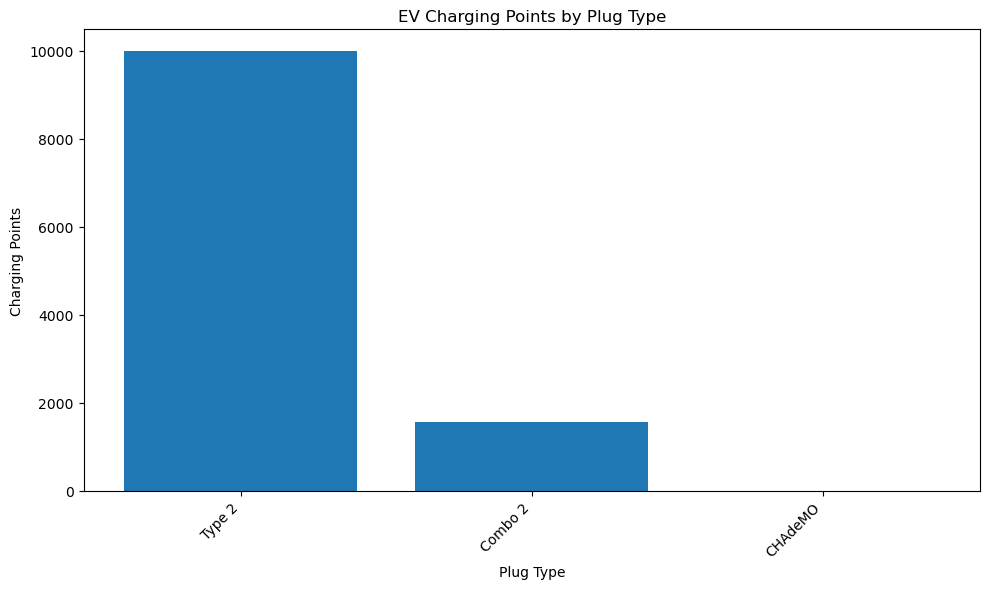

In [14]:
plt.figure(figsize=(10, 6))

plt.bar(
    plug_df.index.astype(str),
    plug_df.values
)

plt.title("EV Charging Points by Plug Type")
plt.xlabel("Plug Type")
plt.ylabel("Charging Points")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

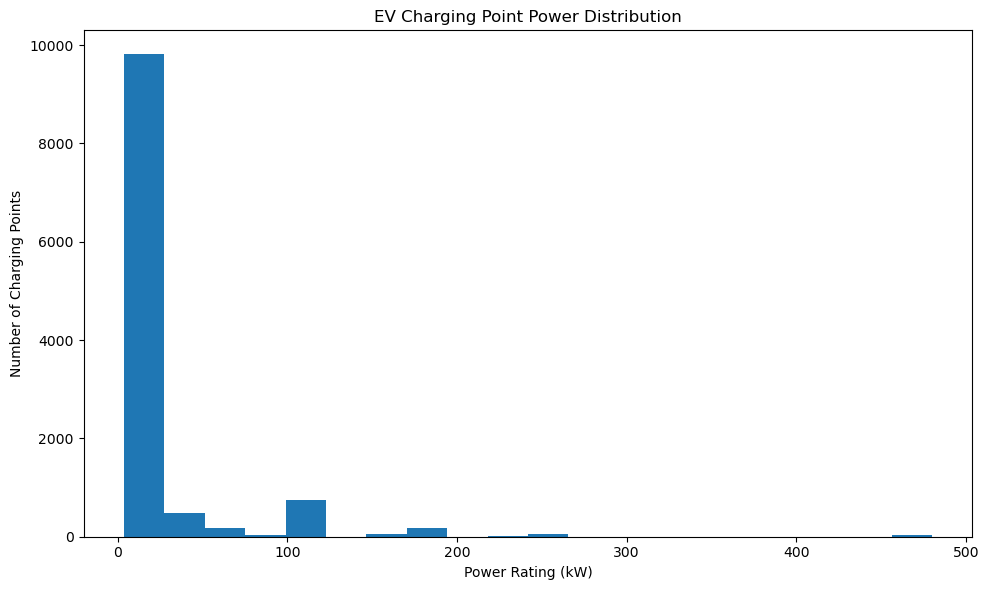

In [15]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["power_rating_kw"].dropna(),
    bins=20
)

plt.title("EV Charging Point Power Distribution")
plt.xlabel("Power Rating (kW)")
plt.ylabel("Number of Charging Points")

plt.tight_layout()
plt.show()

In [16]:
df["power_rating_kw"].describe()

count    11560.000000
mean        24.537837
std         46.010007
min          3.700000
25%          7.000000
50%          7.400000
75%         22.000000
max        480.000000
Name: power_rating_kw, dtype: float64

In [17]:
df["charger_status"].value_counts(dropna=False)

charger_status
1      9508
0      1855
100     197
Name: count, dtype: Int64

In [18]:
status_df = (
    df.groupby("charger_status")["ev_cp_id"]
      .nunique()
)

status_df

charger_status
0      1855
1      9508
100     197
Name: ev_cp_id, dtype: int64

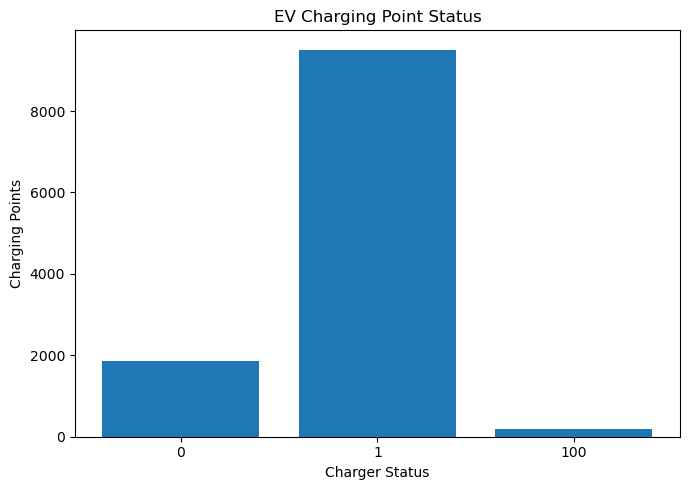

In [19]:
plt.figure(figsize=(7, 5))

plt.bar(
    status_df.index.astype(str),
    status_df.values
)

plt.title("EV Charging Point Status")
plt.xlabel("Charger Status")
plt.ylabel("Charging Points")

plt.tight_layout()
plt.show()

In [20]:
geo_df = df[
    df["latitude"].notna() &
    df["longitude"].notna()
].copy()

print(len(geo_df))

11560


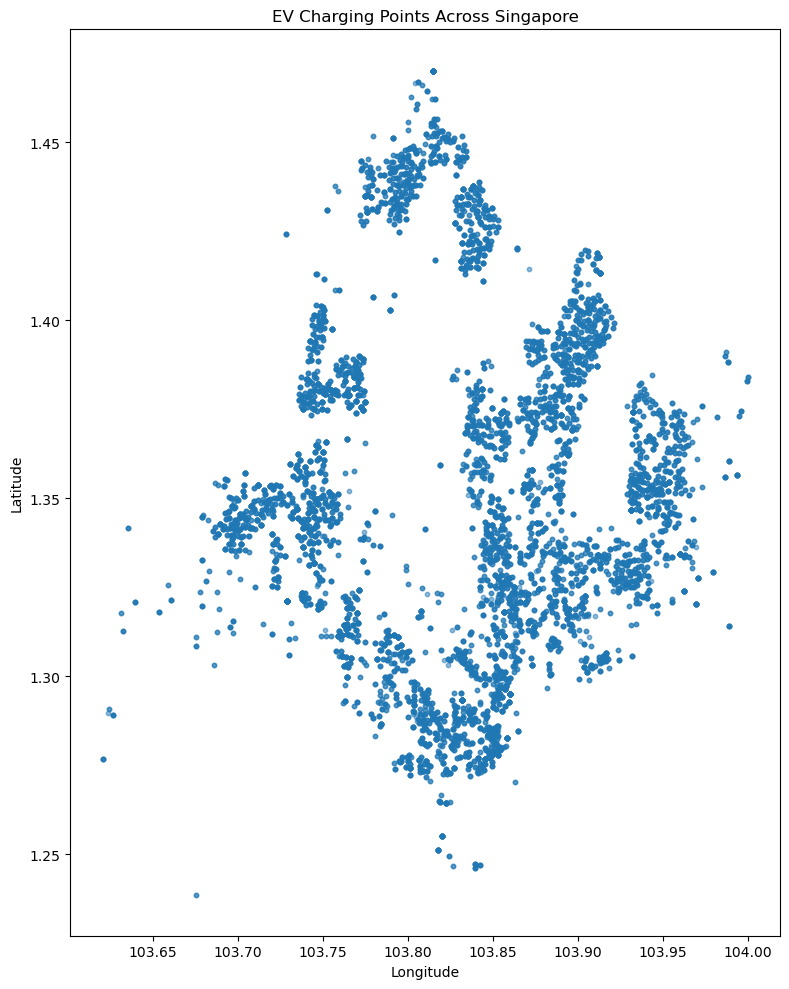

In [21]:
plt.figure(figsize=(8, 10))

plt.scatter(
    geo_df["longitude"],
    geo_df["latitude"],
    s=10,
    alpha=0.5
)

plt.title("EV Charging Points Across Singapore")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

In [22]:
postal_df = (
    df.dropna(subset=["postal_code"])
      .groupby("postal_code")["ev_cp_id"]
      .nunique()
      .sort_values(ascending=False)
      .head(15)
)

postal_df

postal_code
619835    78
237994    64
038983    28
529757    28
758060    28
544886    24
608521    20
519612    20
090032    20
486150    20
048423    19
649674    18
528764    18
208539    16
680205    16
Name: ev_cp_id, dtype: int64

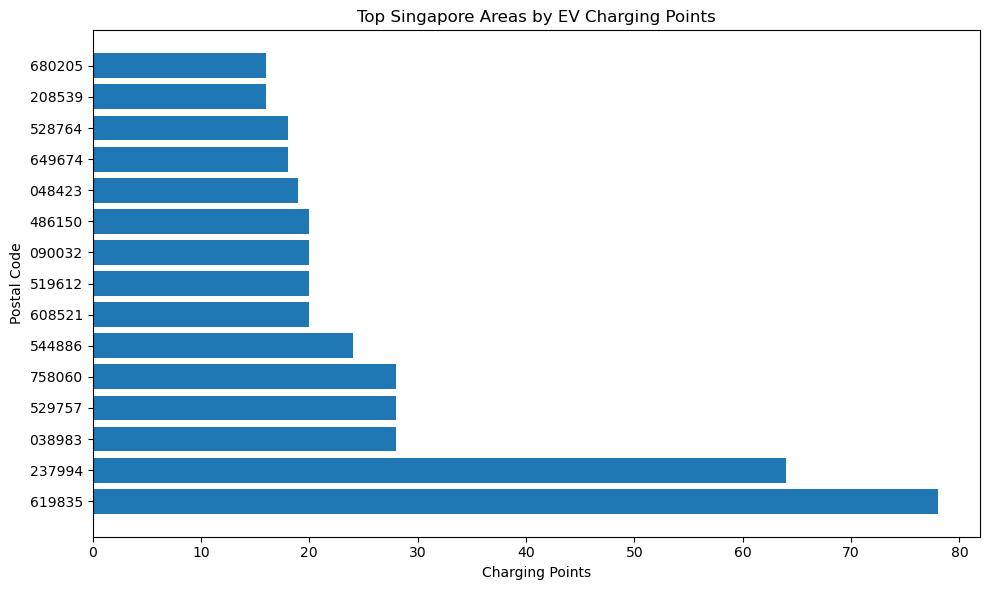

In [23]:
plt.figure(figsize=(10, 6))

plt.barh(
    postal_df.index.astype(str),
    postal_df.values
)

plt.title("Top Singapore Areas by EV Charging Points")
plt.xlabel("Charging Points")
plt.ylabel("Postal Code")

plt.tight_layout()
plt.show()

Plot based on postal code

In [27]:
import pandas as pd
import matplotlib.pyplot as plt


def singapore_region(postal_code):
    if pd.isna(postal_code):
        return "Unknown"

    # Convert postal code to 6-digit string
    postal = str(postal_code).replace(".0", "").zfill(6)

    # First 2 digits
    sector = int(postal[:2])

    if 1 <= sector <= 8:
        return "Central"
    elif 9 <= sector <= 16:
        return "South"
    elif 17 <= sector <= 20:
        return "Central"
    elif 21 <= sector <= 30:
        return "East"
    elif 31 <= sector <= 52:
        return "Central"
    elif 53 <= sector <= 57:
        return "North"
    elif 58 <= sector <= 71:
        return "West"
    elif 72 <= sector <= 82:
        return "North"
    else:
        return "Other"


# Create region
df["region"] = df["postal_code"].apply(singapore_region)

# Count unique charging points
region_df = (
    df.groupby("region")["ev_cp_id"]
      .nunique()
      .sort_values(ascending=False)
)

# Summary table
region_summary = pd.DataFrame({
    "charging_points": region_df
})

region_summary["percentage"] = (
    region_summary["charging_points"]
    / region_summary["charging_points"].sum()
    * 100
).round(2)

display(region_summary)

,charging_points,percentage
region,,
North,3597,31.12
Central,3539,30.61
West,2597,22.47
South,1312,11.35
East,515,4.46


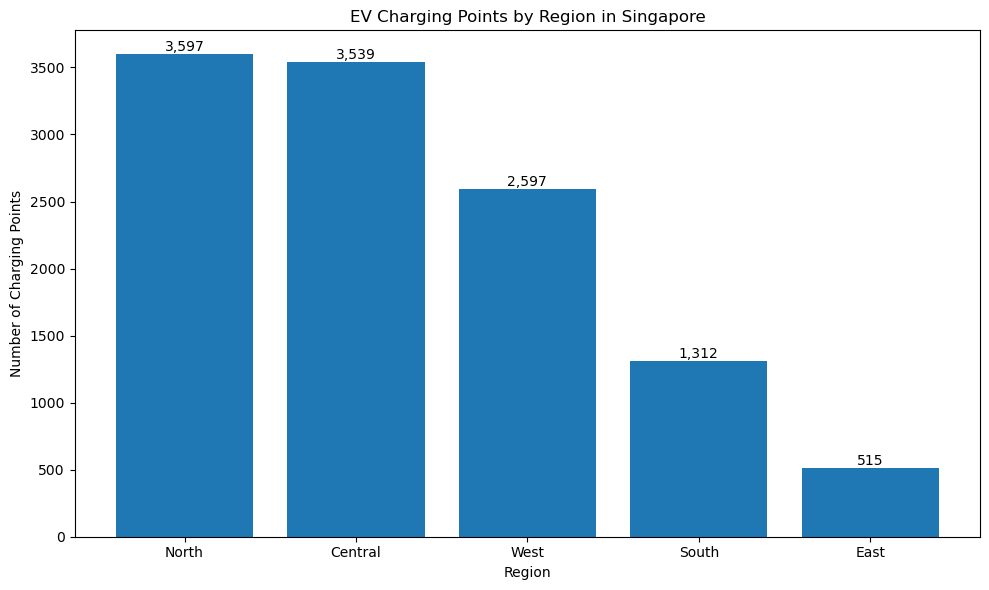

In [28]:
plt.figure(figsize=(10, 6))

plt.bar(
    region_summary.index,
    region_summary["charging_points"]
)

plt.title("EV Charging Points by Region in Singapore")
plt.xlabel("Region")
plt.ylabel("Number of Charging Points")

# Add values above bars
for i, value in enumerate(region_summary["charging_points"]):
    plt.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

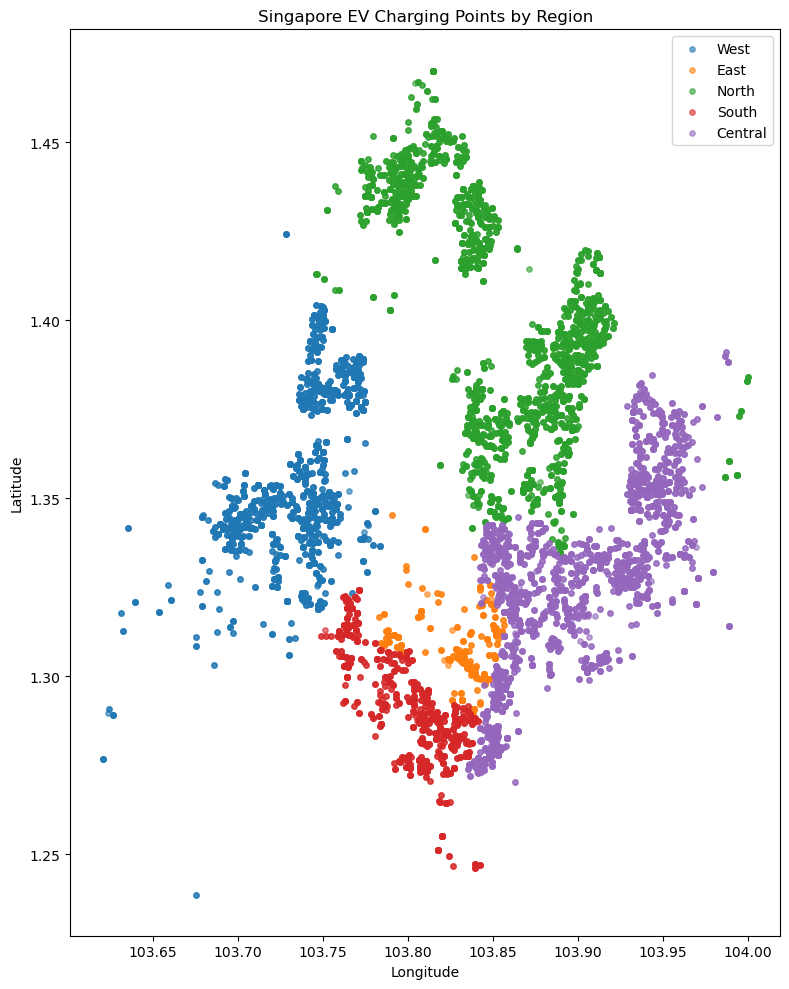

In [30]:
plt.figure(figsize=(8, 10))

for region in ["West", "East", "North", "South", "Central"]:
    subset = df[
        (df["region"] == region) &
        df["latitude"].notna() &
        df["longitude"].notna()
    ]

    plt.scatter(
        subset["longitude"],
        subset["latitude"],
        label=region,
        s=15,
        alpha=0.6
    )

plt.title("Singapore EV Charging Points by Region")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()

plt.tight_layout()
plt.show()